<a href="https://colab.research.google.com/github/A-Ohanusi/Credit-Risk-Model-for-Lending-Against-Bitcoin-Collateral/blob/main/Merton_Model_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
def merton_pd(asset_value, debt, asset_volatility, risk_free_rate, time_horizon):
    dd = (
        np.log(asset_value / debt)
        + (risk_free_rate - 0.5 * asset_volatility**2) * time_horizon
    ) / (asset_volatility * np.sqrt(time_horizon))

    pd = norm.cdf(-dd)

    return dd, pd

In [ ]:
asset_value = 100
debt = 70
asset_volatility = 0.25
risk_free_rate = 0.04
time_horizon = 1

dd, pd = merton_pd(
    asset_value,
    debt,
    asset_volatility,
    risk_free_rate,
    time_horizon
)

print("Distance to Default:", dd)
print("Probability of Default:", pd)

Distance to Default: 1.4616997757549295
Probability of Default: 0.07191174936795149


In [ ]:
scenarios = [
    {"name": "Low debt", "asset_value": 100, "debt": 50, "vol": 0.25},
    {"name": "Medium debt", "asset_value": 100, "debt": 70, "vol": 0.25},
    {"name": "High debt", "asset_value": 100, "debt": 90, "vol": 0.25},
]

for s in scenarios:
    dd, pd = merton_pd(s["asset_value"], s["debt"], s["vol"], 0.04, 1)
    print(s["name"], "DD:", round(dd, 3), "PD:", round(pd, 4))

Low debt DD: 2.808 PD: 0.0025
Medium debt DD: 1.462 PD: 0.0719
High debt DD: 0.456 PD: 0.324


In [ ]:
debts = np.arange(40,95,5)

PDs = []

for D in debts:

    DD, PD = merton_pd(
        asset_value=100,
        debt=D,
        asset_volatility=0.25,
        risk_free_rate=0.04,
        time_horizon=1
    )

    PDs.append(PD)

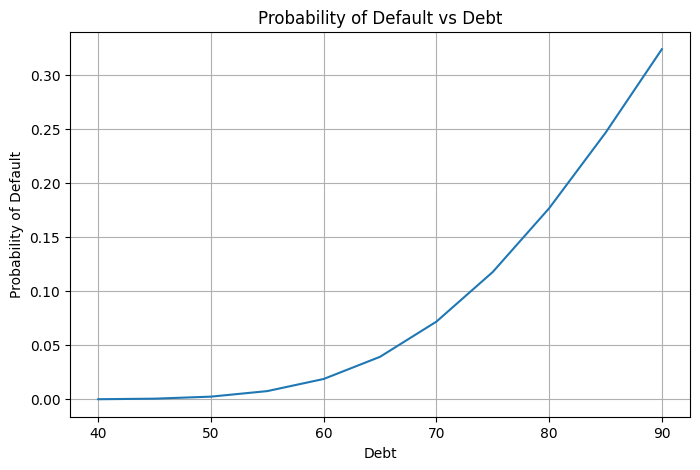

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(debts,PDs)

plt.xlabel("Debt")

plt.ylabel("Probability of Default")

plt.title("Probability of Default vs Debt")

plt.grid()

plt.show()